TP 2 (autonome) : Détection de fraude Mobile Money avec K-means
----------------------------------------------------------------
CONTEXTE
Tu es data scientist chez un opérateur de Mobile Money en Afrique de l'Ouest.
Tu reçois un extrait de 8 130 transactions SANS étiquettes. Le service
conformité soupçonne que quelques fraudes s'y cachent (moins de 2 %),
mais personne ne sait lesquelles ni de quel type.

TA MISSION
1. Explorer les données : types de variables, distributions, asymétries.
2. Préparer les données pour K-means. Attention, c'est moins direct que
   dans le TP 1. Réfléchis à ces trois points avant de coder :
     - `type_transaction` est une variable catégorielle ;
     - `heure` est cyclique : 23h et 0h sont proches, mais pas numériquement ;
     - un montant de 50 000 FCFA n'a pas le même sens selon le solde du compte.
       Peux-tu créer une variable plus parlante ?
3. Choisir k, entraîner K-means, décrire chaque cluster en langage métier.
4. Construire un score d'anomalie et une règle d'alerte (tu peux combiner
   plusieurs signaux, comme dans le TP 1).
5. Sortir la liste des 20 transactions les plus suspectes, avec pour chacune
   une phrase qui explique POURQUOI elle est suspecte.
6. SEULEMENT À LA FIN : charger labels_A_OUVRIR_A_LA_FIN.csv, calculer
   précision et rappel, et analyser quels types de fraude tu rates et pourquoi.

RÈGLES
- Pas d'ouverture du fichier de labels avant l'étape 6.
- Tu peux t'appuyer sur le TP 1 comme référence, mais pas copier-coller :
  les variables et les pièges ne sont pas les mêmes.
- Garde une trace de tes choix en commentaires (pourquoi ce k ? ce seuil ?).

OBJECTIF CHIFFRÉ (indicatif) : rappel > 0.90 avec une précision > 0.50.
C'est atteignable avec K-means seul et un bon prétraitement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("transactions_mobile_money.csv")

In [2]:
#Dans cette artie j'essaie de visualiser les données pour voir la structure du dataset
print(df.shape)
print(df.head())
print(df.describe())
print(df.dtypes)

(8130, 9)
  id_transaction   type_transaction  montant_fcfa  heure  solde_avant_fcfa  \
0       TX000000  paiement_marchand        4220.0  15.81           15470.0   
1       TX000001          transfert       19860.0  18.33           77810.0   
2       TX000002            retrait        8850.0   8.94           35060.0   
3       TX000003            retrait        4160.0  12.02           85880.0   
4       TX000004            retrait        6190.0  16.69          126580.0   

   nb_transactions_24h  anciennete_compte_jours  nouvel_appareil  \
0                    4                     1383                0   
1                    5                     1321                0   
2                    4                     2134                0   
3                    5                     2243                0   
4                    4                      257                0   

   distance_habituelle_km  
0                     1.8  
1                     1.7  
2                     7.6  


In [3]:
col_id = ["id_transaction"] #j'isole la colonne id pour ne pas l'utiliser dans le clustering
X=df.drop(columns=col_id)
print(df.nunique()) # pour voir le nombre de valeurs uniques par variable
X["montant_norm"] = (
    X["montant_fcfa"].astype(float) /
    X["solde_avant_fcfa"].astype(float)
)#feature ingeniering: je creer une new variable pour obtenir plus d'iinfos sur le montant des transactions
col_bin = X.loc[:, X.nunique() == 2].columns.tolist()
col_num=X.select_dtypes(include=np.number).columns.difference(col_bin).tolist()
col_cat=X.select_dtypes(include="object").columns.difference(col_bin).tolist()
#j'isole les différents type de colonnes pour pouvoir les traiter separements
print("Colonnes binaires :", col_bin)
print("Colonnes numériques :", col_num)
print("Colonnes catégorielles :", col_cat)

id_transaction             8130
type_transaction              4
montant_fcfa               3126
heure                      1766
solde_avant_fcfa           6676
nb_transactions_24h          38
anciennete_compte_jours    2775
nouvel_appareil               2
distance_habituelle_km      273
dtype: int64
Colonnes binaires : ['nouvel_appareil']
Colonnes numériques : ['anciennete_compte_jours', 'distance_habituelle_km', 'heure', 'montant_fcfa', 'montant_norm', 'nb_transactions_24h', 'solde_avant_fcfa']
Colonnes catégorielles : ['type_transaction']


C:\Users\farou\AppData\Local\Temp\ipykernel_4684\4032045199.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_cat=X.select_dtypes(include="object").columns.difference(col_bin).tolist()


In [4]:
print(X[col_cat].head())
x=pd.get_dummies(X[col_cat], dtype=int)
X=X.drop(columns=col_cat)
X=pd.concat([X,x],axis=1)
col_cat = x.columns.tolist()
print("Colonnes catégorielles après one-hot encoding :", col_cat)
print(X[col_cat].head())
# ici j'encode la variable catégorielle avec one hot encoding (vu que ya pas d'ordre logique)

    type_transaction
0  paiement_marchand
1          transfert
2            retrait
3            retrait
4            retrait
Colonnes catégorielles après one-hot encoding : ['type_transaction_depot', 'type_transaction_paiement_marchand', 'type_transaction_retrait', 'type_transaction_transfert']
   type_transaction_depot  type_transaction_paiement_marchand  \
0                       0                                   1   
1                       0                                   0   
2                       0                                   0   
3                       0                                   0   
4                       0                                   0   

   type_transaction_retrait  type_transaction_transfert  
0                         0                           0  
1                         0                           1  
2                         1                           0  
3                         1                           0  
4                     

       anciennete_compte_jours  distance_habituelle_km        heure  \
count              8130.000000              8130.00000  8130.000000   
mean               1497.039237                 5.20460    13.892953   
std                 855.200109                18.81345     4.012329   
min                   1.000000                 0.00000     0.800000   
25%                 762.000000                 1.10000    11.270000   
50%                1486.000000                 2.70000    13.910000   
75%                2232.000000                 5.50000    16.660000   
max                2999.000000               380.20000    23.990000   

       montant_fcfa  montant_norm  nb_transactions_24h  solde_avant_fcfa  
count  8.130000e+03   8130.000000          8130.000000      8.130000e+03  
mean   2.231688e+04      0.201416             4.260025      1.209627e+05  
std    1.253505e+05      0.200511             3.763659      1.907283e+05  
min    2.100000e+02      0.000388             1.000000      

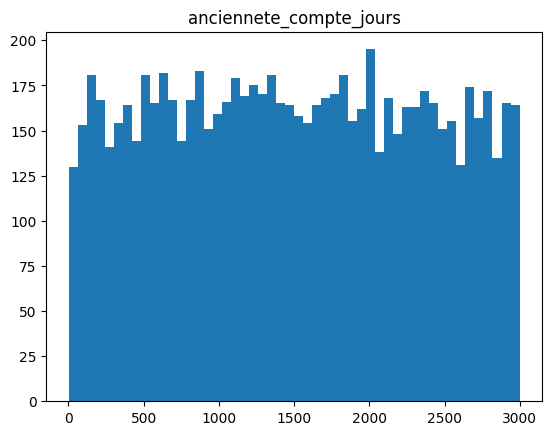

0.01609149050071964


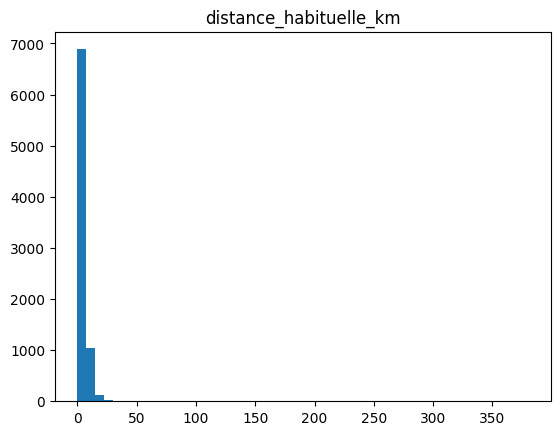

14.790628958009881


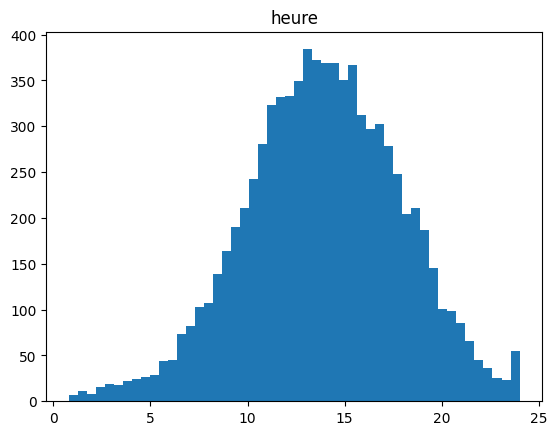

-0.14571287178485737


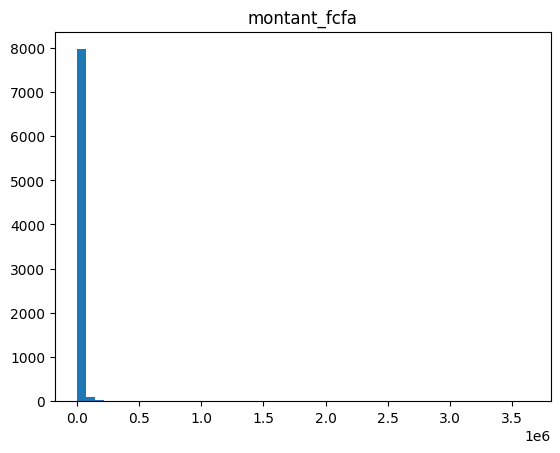

18.058658715713538


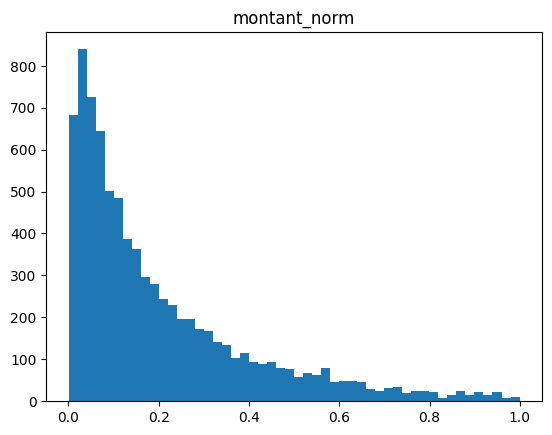

1.5437849328252151


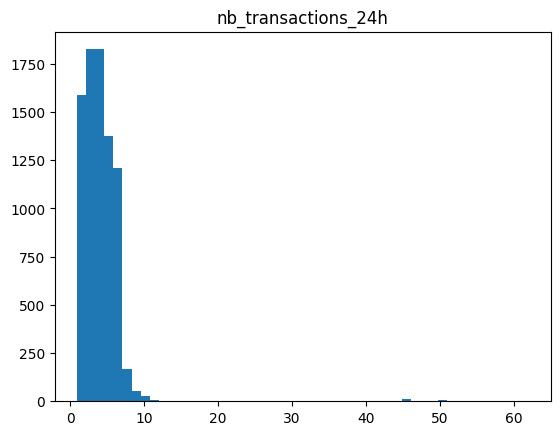

9.307876016538776


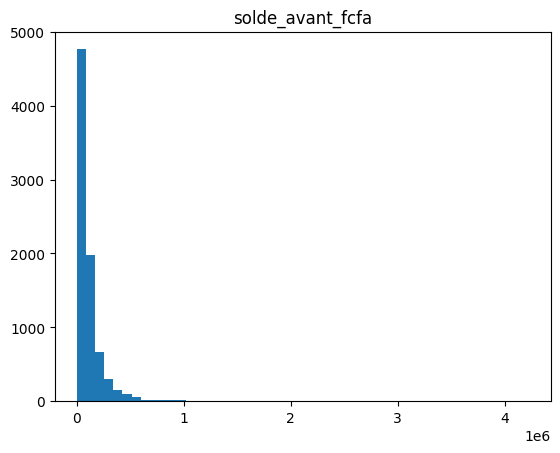

9.127812660539698


In [5]:
print(X[col_num].describe())
for col in col_num:
    plt.figure()
    plt.hist(X[col], bins=50)
    plt.title(col)
    plt.show()
    print(X[col].skew())
#ici je visualise les distributions et le skewness afin de p ouvoir determiner les transformations que je peux apporter 

In [6]:
W = X.copy()
#je travail sur une copie pour ne pas alterer les données originales

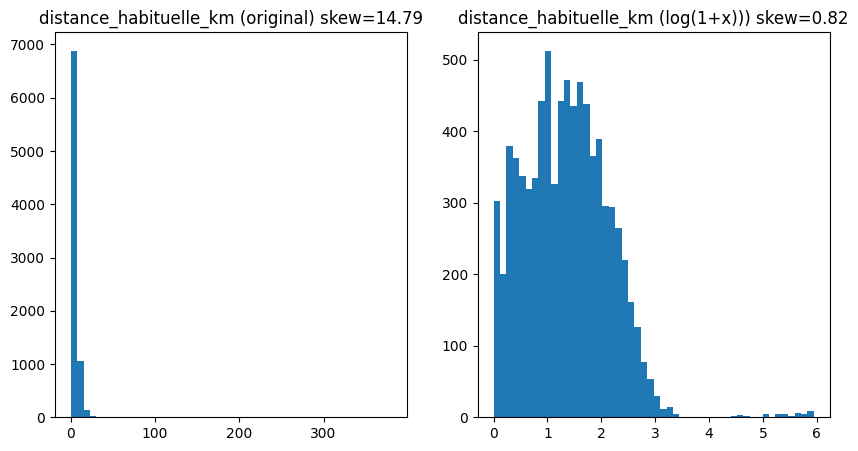

In [7]:
W["distance_habituelle_km"]=np.log(1+W["distance_habituelle_km"])
fig, axs=plt.subplots(1,2,figsize=(10,5))
axs[1].hist(W["distance_habituelle_km"], bins=50)
axs[1].set_title(f"distance_habituelle_km (log(1+x))) skew={W['distance_habituelle_km'].skew():.2f}")
axs[0].hist(X["distance_habituelle_km"], bins=50)
axs[0].set_title(f"distance_habituelle_km (original) skew={X['distance_habituelle_km'].skew():.2f}")
plt.show()
# ici la distribution de cette variable etait tres asymetrique a droite, donc j'ai appliqué un log(1+x)  pour la rendre plus symétrique

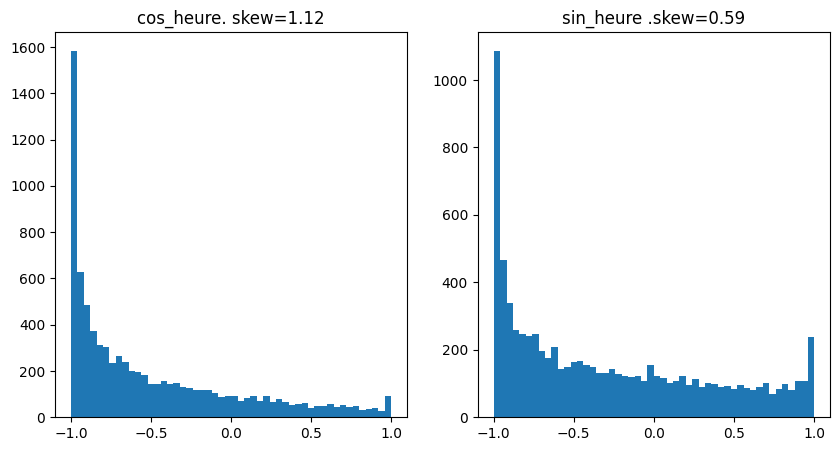

In [8]:
W["sin_heure"]=np.sin(W["heure"]*np.pi/12)
W["cos_heure"]=(np.cos(W["heure"]*np.pi/12))
fig, axs=plt.subplots(1,2,figsize=(10,5))
axs[1].hist(W["sin_heure"], bins=50)
axs[1].set_title(f"sin_heure .skew={W['sin_heure'].skew():.2f}")
axs[0].hist(W["cos_heure"], bins=50)
axs[0].set_title(f"cos_heure. skew={W['cos_heure'].skew():.2f}")
plt.show()
# ici l'heure est une variable cyclique. donc si je la garde tel quelle, 23h et 00h vont semblé tres eloigné alors que ce n'est pas le cas
# donc j'ai appliqué cette transformation en faisant une regle de trois 

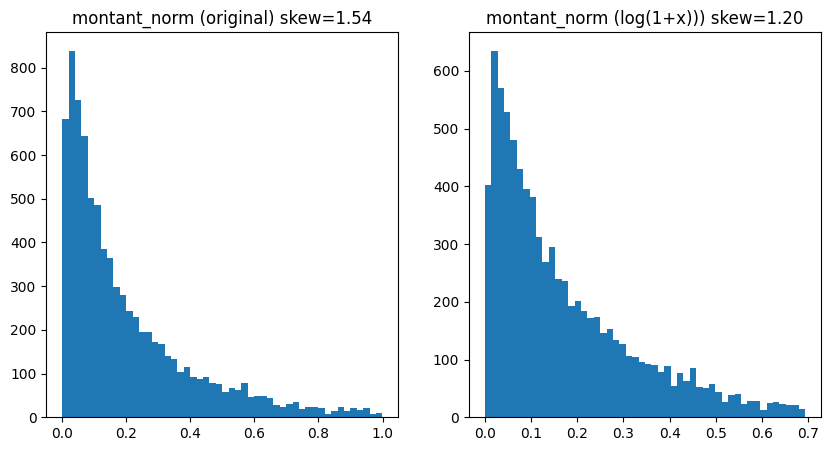

In [9]:
W["montant_norm"]=np.log(W["montant_norm"]+1)
fig, axs=plt.subplots(1,2,figsize=(10,5))
axs[1].hist(W["montant_norm"], bins=50)
axs[1].set_title(f"montant_norm (log(1+x))) skew={W['montant_norm'].skew():.2f}")
axs[0].hist(X["montant_norm"], bins=50)
axs[0].set_title(f"montant_norm (original) skew={X['montant_norm'].skew():.2f}")
plt.show()
# ici la distribution de cette variable etait asymetrique avec une queue assez longue donc j'ai appliquer cette transformation
# pour reduire un peu le skew

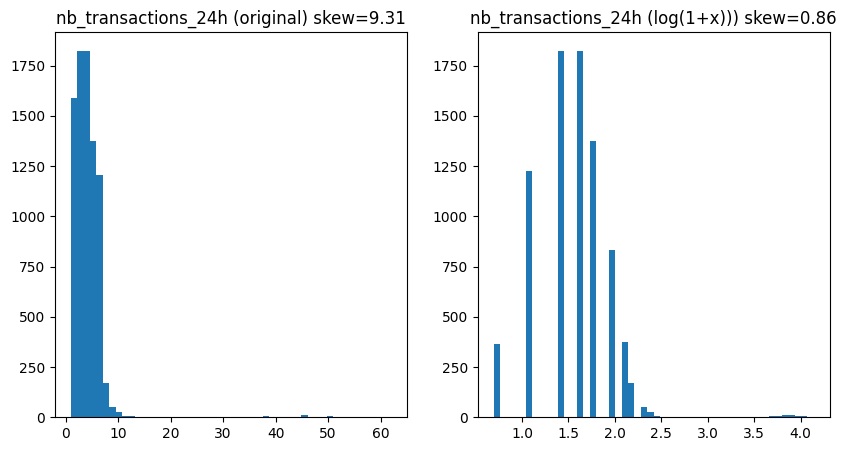

In [10]:
W["nb_transactions_24h"]=np.log(W["nb_transactions_24h"]+1)
fig, axs=plt.subplots(1,2,figsize=(10,5))
axs[1].hist(W["nb_transactions_24h"], bins=50)
axs[1].set_title(f"nb_transactions_24h (log(1+x))) skew={W['nb_transactions_24h'].skew():.2f}")
axs[0].hist(X["nb_transactions_24h"], bins=50)
axs[0].set_title(f"nb_transactions_24h (original) skew={X['nb_transactions_24h'].skew():.2f}")
plt.show()
# ici la distribution de cette variable etait tres asymetrique a droite, donc j'ai appliqué un log(1+x)  pour la rendre plus symétrique

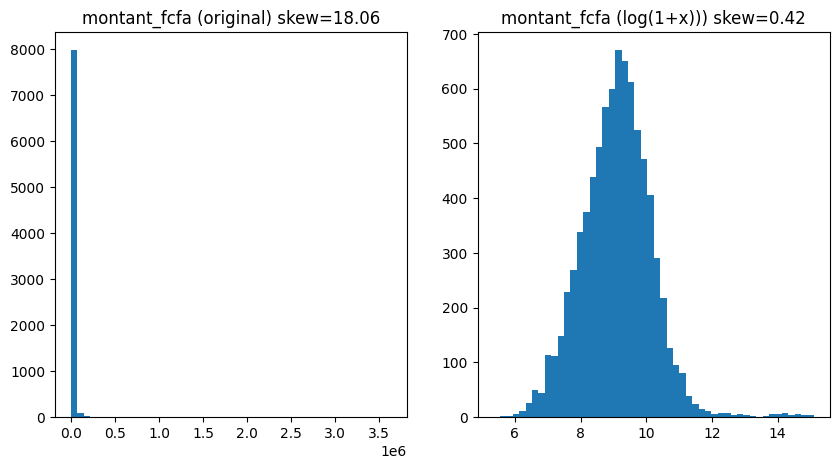

In [11]:
W["montant_fcfa"]=np.log(W["montant_fcfa"]+1)
fig, axs=plt.subplots(1,2,figsize=(10,5))
axs[1].hist(W["montant_fcfa"], bins=50)
axs[1].set_title(f"montant_fcfa (log(1+x))) skew={W['montant_fcfa'].skew():.2f}")
axs[0].hist(X["montant_fcfa"], bins=50)
axs[0].set_title(f"montant_fcfa (original) skew={X['montant_fcfa'].skew():.2f}")
plt.show()
# ici la distribution de cette variable etait tres asymetrique a droite, donc j'ai appliqué un log(1+x)  pour la rendre plus symétrique

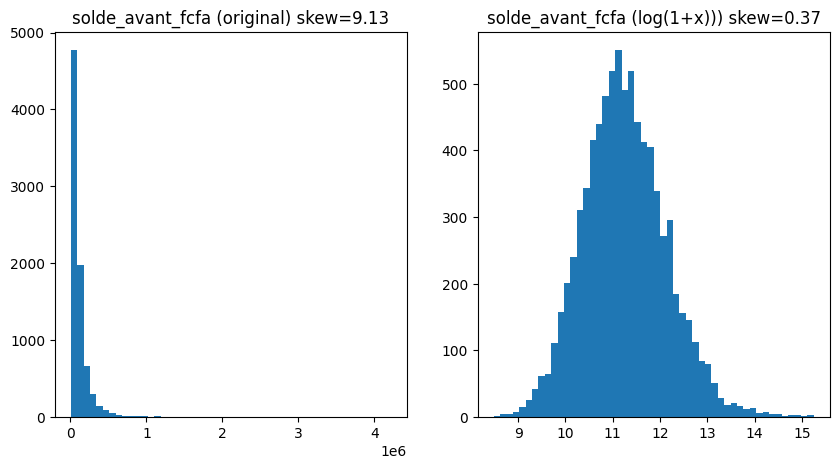

In [12]:
W["solde_avant_fcfa"]=np.log(W["solde_avant_fcfa"]+1)
fig, axs=plt.subplots(1,2,figsize=(10,5))
axs[1].hist(W["solde_avant_fcfa"], bins=50)
axs[1].set_title(f"solde_avant_fcfa (log(1+x))) skew={W['solde_avant_fcfa'].skew():.2f}")
axs[0].hist(X["solde_avant_fcfa"], bins=50)
axs[0].set_title(f"solde_avant_fcfa (original) skew={X['solde_avant_fcfa'].skew():.2f}")
plt.show()
# ici la distribution de cette variable etait tres asymetrique a droite, donc j'ai appliqué un log(1+x)  pour la rendre plus symétrique

In [13]:
col_num.append("sin_heure")
col_num.append("cos_heure")
col_num.remove("heure")
# ici je supprime la colone heure dans col_num car elle ne sert plus vu que j'ai les sin et cos 
W.drop(columns=["heure"], inplace=True)
X.drop(columns=["heure"], inplace=True)
#ici je supprime carrément la colonne heure dans W et X pour ne pas l'utiliser par erreur 

       anciennete_compte_jours  distance_habituelle_km  montant_fcfa  \
count              8130.000000             8130.000000   8130.000000   
mean               1497.039237                1.351590      9.101434   
std                 855.200109                0.786336      1.067267   
min                   1.000000                0.000000      5.351858   
25%                 762.000000                0.741937      8.417041   
50%                1486.000000                1.308333      9.131405   
75%                2232.000000                1.871802      9.765862   
max                2999.000000                5.943324     15.105875   

       montant_norm  nb_transactions_24h  solde_avant_fcfa    sin_heure  \
count   8130.000000          8130.000000       8130.000000  8130.000000   
mean       0.171245             1.563001         11.257111    -0.287299   
std        0.151917             0.397197          0.879225     0.622719   
min        0.000388             0.693147          8

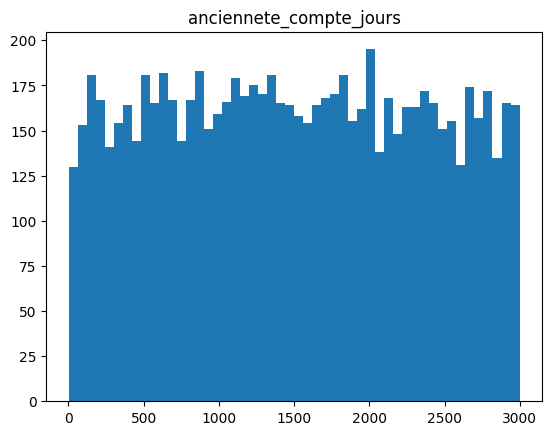

0.01609149050071964


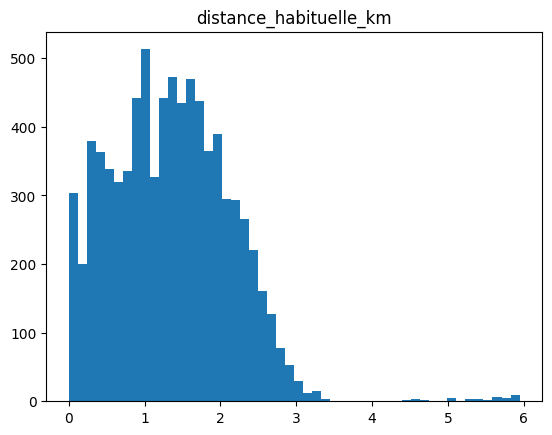

0.8157075909212902


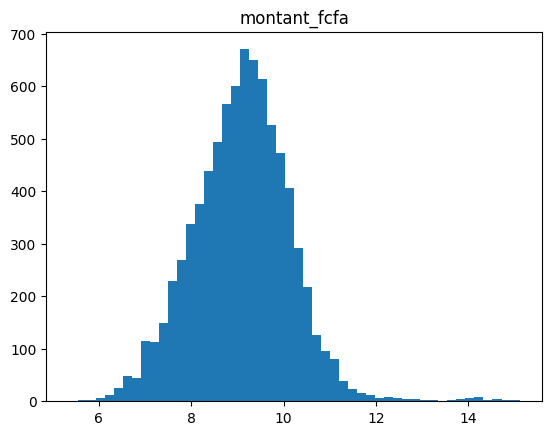

0.41786056487710277


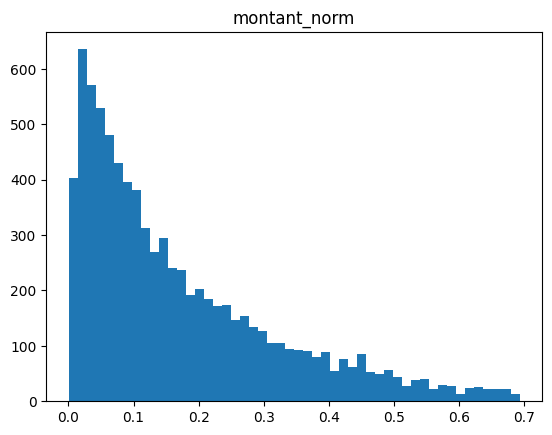

1.2016732207830594


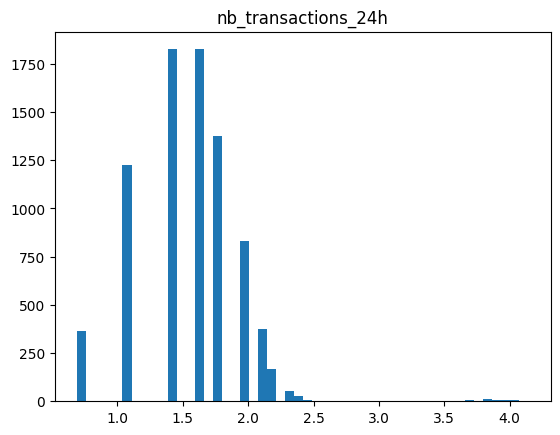

0.8578372330296329


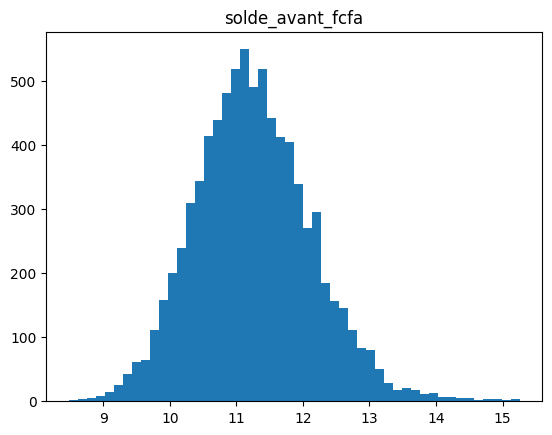

0.3664777524868945


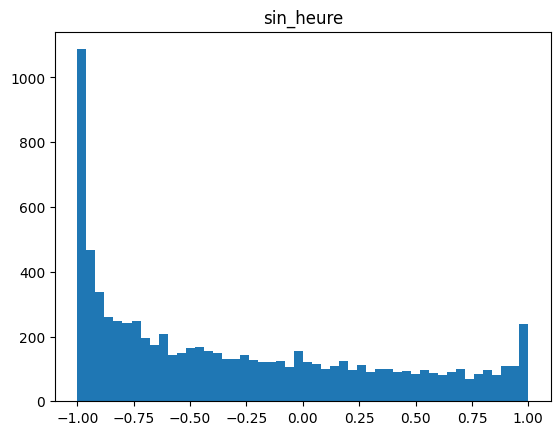

0.5859720665646514


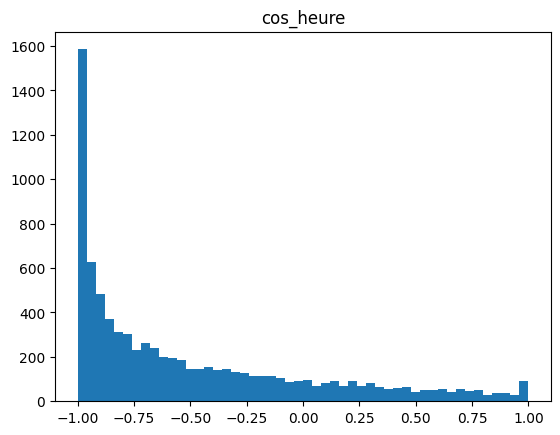

1.1215560331138634


In [14]:
print(W[col_num].describe())
for col in col_num:
    plt.figure()
    plt.hist(W[col], bins=50)
    plt.title(col)
    plt.show()
    print(W[col].skew())

In [15]:
from sklearn import cluster
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
W[col_num] = scaler.fit_transform(W[col_num])

In [16]:
print(W[col_num].describe())

       anciennete_compte_jours  distance_habituelle_km  montant_fcfa  \
count             8.130000e+03            8.130000e+03  8.130000e+03   
mean             -1.048772e-17            9.264149e-17 -4.247525e-16   
std               1.000062e+00            1.000062e+00  1.000062e+00   
min              -1.749452e+00           -1.718952e+00 -3.513464e+00   
25%              -8.595467e-01           -7.753562e-01 -6.412965e-01   
50%              -1.290916e-02           -5.501471e-02  2.808445e-02   
75%               8.594549e-01            6.616053e-01  6.225893e-01   
max               1.756376e+00            5.839765e+00  5.626341e+00   

       montant_norm  nb_transactions_24h  solde_avant_fcfa     sin_heure  \
count  8.130000e+03         8.130000e+03      8.130000e+03  8.130000e+03   
mean   5.243858e-18         3.723139e-16      1.435943e-15  1.791651e-17   
std    1.000062e+00         1.000062e+00      1.000062e+00  1.000062e+00   
min   -1.124743e+00        -2.190113e+00     -3

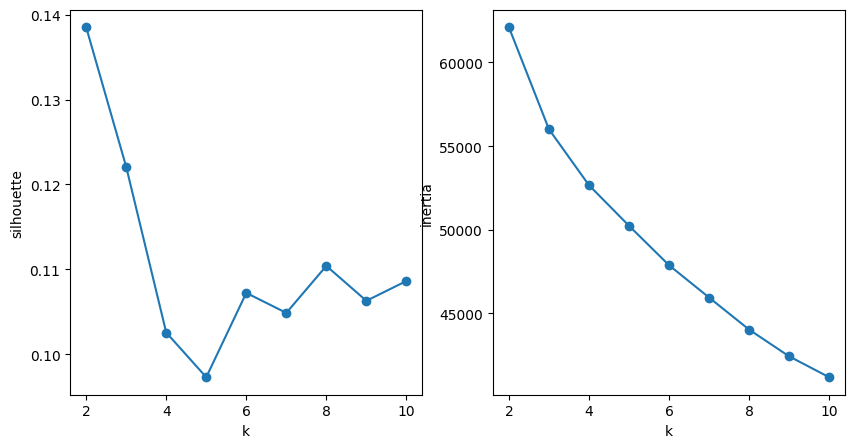

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

res=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,n_init=10, random_state=42)
    kmeans.fit(W)
    s = silhouette_score(W, kmeans.labels_,sample_size=3000)
    c = kmeans.inertia_
    p = np.bincount(kmeans.labels_) #compte les points par cluster.
    res.append([k,s,c,p])
df_res=pd.DataFrame(res, columns=["k","silhouette","inertia","points_par_cluster"])    

fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].plot(df_res["k"], df_res["silhouette"], marker="o")
axs[0].set_xlabel("k")
axs[0].set_ylabel("silhouette")
axs[1].plot(df_res["k"], df_res["inertia"], marker="o")
axs[1].set_xlabel("k")
axs[1].set_ylabel("inertia")
plt.show()

In [18]:
print(df_res.round(2))
# Apres visualisation, je constate que 

    k  silhouette   inertia                                 points_par_cluster
0   2        0.14  62104.53                                       [2912, 5218]
1   3        0.12  56011.69                                 [1922, 3616, 2592]
2   4        0.10  52666.34                           [1735, 2106, 2249, 2040]
3   5        0.10  50242.05                     [1564, 1578, 1781, 1702, 1505]
4   6        0.11  47885.05                 [1640, 1411, 1669, 1754, 1571, 85]
5   7        0.10  45955.46           [1464, 1148, 1215, 1456, 85, 1452, 1310]
6   8        0.11  44038.80       [1499, 1164, 1199, 1407, 1287, 84, 1440, 50]
7   9        0.11  42440.72  [1155, 991, 1079, 50, 1222, 1280, 1253, 1017, 83]
8  10        0.11  41192.09  [971, 896, 1118, 50, 1038, 83, 1025, 1040, 938...


In [19]:
# apres visualisation, je vois que avec la methode de laa silhouette, ya pas vraiment de pic, donc cette methode n'est pas concluente
# Aussi en observant la methode du coude, je vois qu'il n'ya pas vraiment de coude ou plutot le coude est lisse donc ne peux pas me donner une reel information
# Ainsi donc en observant le nmbre de points dans chaque cluster pour chaque k je constate que c'est a k =8 que ya 2 petits clusters qui se forme et qui ont une 
# vleur a peu pres stable quand k augmente, Au dela de k=8, les gros clusters se divisent juste succesivement sans rien changer de nouveau
# en conclusion on prendra k = 8 pour le clustering
k = 8
print(f"k optimal: {k}")

k optimal: 8


In [20]:
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(W)
df["cluster"] = kmeans.labels_
#j'enregistre les labels des clusters que j'ai trouver dans le dataframe original pour pouvoir les utiliser plus tard

In [21]:
print(df["cluster"].value_counts().sort_index())
# j'affiche chaque cluster avec le nombre de point qu'il contiznt

cluster
0    1499
1    1164
2    1199
3    1407
4    1287
5      84
6    1440
7      50
Name: count, dtype: int64


In [22]:
print(col_num)

['anciennete_compte_jours', 'distance_habituelle_km', 'montant_fcfa', 'montant_norm', 'nb_transactions_24h', 'solde_avant_fcfa', 'sin_heure', 'cos_heure']


In [23]:
df["montant_norm"] = (
    df["montant_fcfa"].astype(float) /
    df["solde_avant_fcfa"].astype(float)
)
# je rajoute la colone montant_norm dans le dataframe depart pour pouvoir faire les comparaisons

In [24]:
col_num_df = df.select_dtypes(include=np.number).columns.difference(col_bin,).tolist()
col_num_df.remove("cluster")
print(col_num_df)
# je forme les colonnes numeriques pour le dataframe de depart pour pouvoir faire les comparaisons avec le dataframe W

['anciennete_compte_jours', 'distance_habituelle_km', 'heure', 'montant_fcfa', 'montant_norm', 'nb_transactions_24h', 'solde_avant_fcfa']


In [25]:
profils=df.groupby("cluster")[col_num_df].median().round(2)
profils.head(8)

,anciennete_compte_jours,distance_habituelle_km,heure,montant_fcfa,montant_norm,nb_transactions_24h,solde_avant_fcfa
cluster,,,,,,,
0,1597.0,2.6,13.66,21240.0,0.47,4.0,48240.0
1,1469.5,3.1,8.55,8005.0,0.13,4.0,67855.0
2,1244.0,2.5,14.28,2810.0,0.08,4.0,37470.0
3,2447.0,2.7,13.62,7740.0,0.07,4.0,116010.0
4,721.0,2.9,13.70,11120.0,0.08,4.0,152680.0
5,580.0,91.9,4.10,376745.0,0.91,4.0,401670.0
6,1432.5,2.7,19.14,8875.0,0.13,4.0,74885.0
7,6.0,2.3,14.26,18885.0,0.85,46.0,22745.0


In [26]:
profils["portion_nouvel_appareil"] = df.groupby("cluster")["nouvel_appareil"].mean()
profils["nb_transactions"] = df["cluster"].value_counts()
profils["part_trafic"] = df["cluster"].value_counts(normalize=True)
globale = df[col_num_df].median()
globale["portion_nouvel_appareil"] = df["nouvel_appareil"].mean()
globale["nb_transactions"] = len(df)
globale["part_trafic"] = 1.0
profils.loc["GLOBAL"] = globale

print(profils.round(2))
# avec cette partie j'arrive a voir chaque cluster avec ces statistiques. Ainsi je constate que les clusters 7 et 5 sont anormals car deja ce sont les plus petits et aussi par example le cluster 5
# a une distance habituelle tres grande comparé aux autres clusters, se it a des heures inhabituel avec des montants enormes et utilise le plus de nouvel appareil avec le cluster 7
# et que le clusters 7 a qant a lui une ancienneté tres faible par rapport aux autres clusters, utilise aussi des montants enormes, a le plus de nombre de transaction en 1 heure et aussi part generalement d'un nouvel appareil
# Pour les nouvel appareil j'i utilisé le mean parce qu'il etait plus parlant que la median ici, vu ue c'est une variable binaire

         anciennete_compte_jours  distance_habituelle_km  heure  montant_fcfa  \
cluster                                                                         
0                         1597.0                     2.6  13.66       21240.0   
1                         1469.5                     3.1   8.55        8005.0   
2                         1244.0                     2.5  14.28        2810.0   
3                         2447.0                     2.7  13.62        7740.0   
4                          721.0                     2.9  13.70       11120.0   
5                          580.0                    91.9   4.10      376745.0   
6                         1432.5                     2.7  19.14        8875.0   
7                            6.0                     2.3  14.26       18885.0   
GLOBAL                    1486.0                     2.7  13.91        9240.0   

         montant_norm  nb_transactions_24h  solde_avant_fcfa  \
cluster                                     

In [27]:

print(pd.crosstab(df["cluster"], df["type_transaction"], normalize="index").round(2))
# Ici je compare la vriable categorielle pour voir la repartion dans les différents clusters. Ici aussi le constat est bizarre dans le cluster 7 on remrque qu'il n'ya que des transferts, ce qui esr etrange 
# Aussi pour le cluster 5 ont qu'il ya tres peu de depot mais beaucoup plus de paiement de retrait et de transfert 

type_transaction  depot  paiement_marchand  retrait  transfert
cluster                                                       
0                  0.42               0.03     0.33       0.23
1                  0.22               0.18     0.25       0.35
2                  0.06               0.59     0.11       0.25
3                  0.23               0.19     0.24       0.34
4                  0.30               0.12     0.28       0.30
5                  0.05               0.42     0.33       0.20
6                  0.24               0.17     0.26       0.33
7                  0.00               0.00     0.00       1.00


In [28]:
# ici je vais maintenant determiner le score d'anomalie 
centres = kmeans.cluster_centers_[kmeans.labels_]
df["distance"] = np.linalg.norm(W.values - centres, axis=1)
df["score"] = df["distance"] / df.groupby("cluster")["distance"].transform("median")
# On divise par la médiane du cluster parce que certains clusters sont plus étalés que d'autres : une même distance peut être banale dans l'un et suspecte dans l'autre

In [29]:
#ICI on defini les critères d'alertes 
TAUX_ALERTE = 0.02 #d'apres l'enoncé
# Signal 1 : loin du centre de son cluster
seuil = df["score"].quantile(1 - TAUX_ALERTE)
df["alerte_score"] = df["score"] > seuil

# Signal 2 : appartenir à un cluster de moins de 2 % du trafic
part = df["cluster"].map(df["cluster"].value_counts(normalize=True))
df["alerte_petit_cluster"] = part < TAUX_ALERTE

# Combinaison : au moins un des deux signaux
# df["alerte"] = df["alerte_score"] | df["alerte_petit_cluster"]
df["alerte"] = df["alerte_petit_cluster"]


print(df[["alerte_score", "alerte_petit_cluster", "alerte"]].sum())
# au final j'ai 295 alertes que j'ai reussi a detecter ! ce qui  est effectivement inferieur au 2% mentionner dans l'enoncé 

alerte_score            163
alerte_petit_cluster    134
alerte                  134
dtype: int64


In [30]:
from sklearn.metrics import precision_score, recall_score

labels = pd.read_csv("labels_A_OUVRIR_A_LA_FIN.csv")
df = df.merge(labels, on="id_transaction", how="left")
y_true = df["label"] != "normal"

# Performance globale de chaque règle
for col in ["alerte_petit_cluster", "alerte"]:
    print(f"{col:22s} précision={precision_score(y_true, df[col]):.2f} "
          f"rappel={recall_score(y_true, df[col]):.2f}")

# Détail par type de fraude
print(pd.crosstab(df["label"], df["alerte"], margins=True))
print(df[y_true].groupby("label")["alerte"].mean().round(2))

# Dans quels clusters sont tombées les fraudes ?
print(pd.crosstab(df["label"], df["cluster"]))

alerte_petit_cluster   précision=0.97 rappel=1.00
alerte                 précision=0.97 rappel=1.00
alerte         False  True   All
label                           
compte_mule        0    50    50
faux_marchand      0    35    35
normal          7996     4  8000
sim_swap           0    45    45
All             7996   134  8130
label
compte_mule      1.0
faux_marchand    1.0
sim_swap         1.0
Name: alerte, dtype: float64
cluster           0     1     2     3     4   5     6   7
label                                                    
compte_mule       0     0     0     0     0   0     0  50
faux_marchand     0     0     0     0     0  35     0   0
normal         1499  1164  1199  1407  1287   4  1440   0
sim_swap          0     0     0     0     0  45     0   0
